# MAE — Fast Training Version (Kaggle T4×2)

| Change | Original | **Fast Version** |
|---|---|---|
| Epochs | 100 | **20** |
| Warm-up | 10 ep | **3 ep** |
| Dataset subset | 100K images | **20K images** |
| Batch size | 64 | **128** |
| Encoder layers | 12 | **6** |
| Decoder layers | 12 | **4** |
| Image size | 224×224 | **128×128** |
| Patches | 196 | **64** |
| Est. time | ~8 hrs | **~25–35 min** |

## Cell 1 — Install

In [31]:
!pip install -q einops scikit-image gradio

## Cell 2 — Imports & Device

In [32]:
import os, math, random, warnings
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
from torchvision.transforms.functional import to_tensor, normalize as norm_fn
from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity as calc_ssim

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} | GPUs: {torch.cuda.device_count()}')
for i in range(torch.cuda.device_count()):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

Device: cuda | GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## Cell 3 — Config (all speed knobs here)

In [33]:
# ╔══════════════════════════════════════════╗
# ║   FAST-TRAIN CONFIG — edit here only    ║
# ╚══════════════════════════════════════════╝

IMG_SIZE      = 128     # 128 instead of 224 → 64 patches not 196
PATCH_SIZE    = 16      # keep 16×16 (assignment spec)
MASK_RATIO    = 0.75    # keep 75% (assignment requirement)

# Encoder — ViT-Base dims kept, depth halved
ENC_DIM       = 768
ENC_DEPTH     = 6       # 6 instead of 12
ENC_HEADS     = 12

# Decoder — ViT-Small dims kept, depth reduced
DEC_DIM       = 384
DEC_DEPTH     = 4       # 4 instead of 12
DEC_HEADS     = 6

# Training
EPOCHS        = 20
WARMUP_EPOCHS = 3
BATCH_SIZE    = 128
BASE_LR       = 1.5e-4
WEIGHT_DECAY  = 0.05
GRAD_CLIP     = 1.0

# 20% of dataset
TRAIN_SUBSET  = 20000
VAL_SUBSET    = 2000
NUM_WORKERS   = 4
CKPT          = '/kaggle/working/mae_fast.pth'

NUM_PATCHES   = (IMG_SIZE // PATCH_SIZE) ** 2
eff_lr        = BASE_LR * BATCH_SIZE / 256

print(f'Image size  : {IMG_SIZE}x{IMG_SIZE}')
print(f'Patches     : {NUM_PATCHES} total | {int(NUM_PATCHES*0.25)} visible | {int(NUM_PATCHES*0.75)} masked')
print(f'Enc depth   : {ENC_DEPTH} | Dec depth: {DEC_DEPTH}')
print(f'Effective LR: {eff_lr:.2e}')
print(f'Steps/epoch : ~{TRAIN_SUBSET // BATCH_SIZE}')

Image size  : 128x128
Patches     : 64 total | 16 visible | 48 masked
Enc depth   : 6 | Dec depth: 4
Effective LR: 7.50e-05
Steps/epoch : ~156


## Cell 4 — Dataset (20K subset)

In [34]:
TINY_ROOT = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

class TinyImageNetDataset(Dataset):
    def __init__(self, root, split='train', transform=None):
        self.transform = transform
        root = Path(root)
        self.samples = []
        if split == 'train':
            for cls_dir in sorted((root / 'train').iterdir()):
                img_dir = cls_dir / 'images'
                if img_dir.exists():
                    self.samples += list(img_dir.glob('*.JPEG'))
        else:
            val_img = root / 'val' / 'images'
            self.samples = list(val_img.glob('*.JPEG')) if val_img.exists() \
                           else list((root / 'val').glob('**/*.JPEG'))
        self.samples = [str(p) for p in self.samples]
        print(f'[{split}] {len(self.samples):,} images')

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, 0

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)), T.RandomHorizontalFlip(),
    T.ColorJitter(0.4, 0.4, 0.4), T.ToTensor(), T.Normalize(MEAN, STD)
])
val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize(MEAN, STD)
])

full_train = TinyImageNetDataset(TINY_ROOT, 'train', train_tf)
full_val   = TinyImageNetDataset(TINY_ROOT, 'val',   val_tf)

# Random subsets
train_ds = Subset(full_train, random.sample(range(len(full_train)), min(TRAIN_SUBSET, len(full_train))))
val_ds   = Subset(full_val,   random.sample(range(len(full_val)),   min(VAL_SUBSET,   len(full_val))))
print(f'Using {len(train_ds):,} train / {len(val_ds):,} val images')

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

[train] 100,000 images
[val] 10,000 images
Using 20,000 train / 2,000 val images
Train batches: 156 | Val batches: 16


## Cell 5 — Patchify / Masking

In [35]:
def patchify(imgs, p=PATCH_SIZE):
    B, C, H, W = imgs.shape
    h, w = H // p, W // p
    x = imgs.reshape(B, C, h, p, w, p).permute(0, 2, 4, 3, 5, 1)
    return x.reshape(B, h * w, p * p * C)

def unpatchify(x, p=PATCH_SIZE, s=IMG_SIZE):
    h = w = s // p
    x = x.reshape(x.shape[0], h, w, p, p, 3).permute(0, 5, 1, 3, 2, 4)
    return x.reshape(x.shape[0], 3, h * p, w * p)

def random_masking(x, mask_ratio=MASK_RATIO):
    B, N, D  = x.shape
    len_keep = int(N * (1 - mask_ratio))
    noise    = torch.rand(B, N, device=x.device)
    ids_shuf = torch.argsort(noise, dim=1)
    ids_rest = torch.argsort(ids_shuf, dim=1)
    x_vis    = torch.gather(x, 1, ids_shuf[:, :len_keep].unsqueeze(-1).expand(-1, -1, D))
    mask = torch.ones(B, N, device=x.device)
    mask[:, :len_keep] = 0
    mask = torch.gather(mask, 1, ids_rest)
    return x_vis, mask, ids_rest

# Sanity check
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
assert (dummy - unpatchify(patchify(dummy))).abs().max() < 1e-5
vis, msk, _ = random_masking(patchify(dummy))
print(f'Patches: {NUM_PATCHES} | Visible: {vis.shape[1]} | Masked: {int(msk.sum(1).mean())} | Roundtrip OK')

Patches: 64 | Visible: 16 | Masked: 48 | Roundtrip OK


## Cell 6 — Model (Blocks + sincos)

In [36]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=3, embed_dim=768):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x): return self.proj(x).flatten(2).transpose(1, 2)

class MHSA(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.heads    = heads
        self.head_dim = dim // heads
        self.scale    = self.head_dim ** -0.5
        self.qkv      = nn.Linear(dim, dim * 3)
        self.proj     = nn.Linear(dim, dim)
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.heads, self.head_dim)
        q, k, v = qkv.permute(2, 0, 3, 1, 4).unbind(0)
        attn = (q @ k.transpose(-2, -1) * self.scale).softmax(dim=-1)
        return self.proj((attn @ v).transpose(1, 2).reshape(B, N, C))

class Block(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4.):
        super().__init__()
        self.n1 = nn.LayerNorm(dim); self.attn = MHSA(dim, heads)
        self.n2 = nn.LayerNorm(dim)
        h = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, h), nn.GELU(), nn.Linear(h, dim))
    def forward(self, x):
        x = x + self.attn(self.n1(x))
        x = x + self.mlp(self.n2(x))
        return x

def sincos_pos_embed(dim, g):
    assert dim % 4 == 0
    a = np.arange(g, dtype=np.float32)
    gh, gw = np.meshgrid(a, a, indexing='ij')
    def _1d(pos, d):
        w = 1. / (10000 ** (np.arange(d//2, dtype=np.float32) / (d/2.)))
        out = pos.flatten()[:, None] * w[None, :]
        return np.concatenate([np.sin(out), np.cos(out)], axis=1)
    return np.concatenate([_1d(gh, dim//2), _1d(gw, dim//2)], axis=1)

print('Building blocks defined ✓')

Building blocks defined ✓


## Cell 7 — Encoder (6 layers)

In [37]:
class MAEEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = PatchEmbed(IMG_SIZE, PATCH_SIZE, 3, ENC_DIM)
        N = self.patch_embed.num_patches
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, ENC_DIM))
        self.register_buffer('pos_embed', torch.zeros(1, N+1, ENC_DIM), persistent=False)
        self.blocks = nn.ModuleList([Block(ENC_DIM, ENC_HEADS) for _ in range(ENC_DEPTH)])
        self.norm   = nn.LayerNorm(ENC_DIM)
        # init sincos pos embed
        g  = int(N ** .5)
        pe = sincos_pos_embed(ENC_DIM, g)
        self.pos_embed.data[:, 1:].copy_(torch.from_numpy(pe).float().unsqueeze(0))
        nn.init.normal_(self.cls_token, std=0.02)

    def forward(self, imgs, mask_ratio=MASK_RATIO):
        x = self.patch_embed(imgs) + self.pos_embed[:, 1:]
        x, mask, ids = random_masking(x, mask_ratio)
        cls = (self.cls_token + self.pos_embed[:, :1]).expand(x.shape[0], -1, -1)
        x   = torch.cat([cls, x], dim=1)
        for blk in self.blocks: x = blk(x)
        return self.norm(x), mask, ids

_e = MAEEncoder()
print(f'Encoder: {sum(p.numel() for p in _e.parameters())/1e6:.1f}M params  (depth={ENC_DEPTH})')
del _e

Encoder: 43.1M params  (depth=6)


## Cell 8 — Decoder (4 layers)

In [38]:
class MAEDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed      = nn.Linear(ENC_DIM, DEC_DIM)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, DEC_DIM))
        self.register_buffer('pos_embed', torch.zeros(1, NUM_PATCHES+1, DEC_DIM), persistent=False)
        self.blocks = nn.ModuleList([Block(DEC_DIM, DEC_HEADS) for _ in range(DEC_DEPTH)])
        self.norm   = nn.LayerNorm(DEC_DIM)
        self.pred   = nn.Linear(DEC_DIM, PATCH_SIZE**2 * 3)
        # init
        g  = int(NUM_PATCHES ** .5)
        pe = sincos_pos_embed(DEC_DIM, g)
        self.pos_embed.data[:, 1:].copy_(torch.from_numpy(pe).float().unsqueeze(0))
        nn.init.normal_(self.mask_token, std=0.02)

    def forward(self, latent, ids_restore):
        x = self.embed(latent)
        n_mask   = ids_restore.shape[1] - (x.shape[1] - 1)
        mask_tok = self.mask_token.expand(x.shape[0], n_mask, -1)
        x_pat    = torch.cat([x[:, 1:], mask_tok], dim=1)
        x_pat    = torch.gather(x_pat, 1, ids_restore.unsqueeze(-1).expand(-1, -1, x_pat.shape[-1]))
        x = torch.cat([x[:, :1], x_pat], dim=1) + self.pos_embed
        for blk in self.blocks: x = blk(x)
        return self.pred(self.norm(x)[:, 1:])

_d = MAEDecoder()
print(f'Decoder: {sum(p.numel() for p in _d.parameters())/1e6:.1f}M params  (depth={DEC_DEPTH})')
del _d

Decoder: 7.7M params  (depth=4)


## Cell 9 — Full MAE + Smoke Test

In [39]:
class MAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = MAEEncoder()
        self.decoder = MAEDecoder()

    def patchify(self, imgs):   return patchify(imgs)
    def unpatchify(self, x):    return unpatchify(x)

    def compute_loss(self, imgs, pred, mask):
        target = self.patchify(imgs)
        mean   = target.mean(-1, keepdim=True)
        var    = target.var(-1,  keepdim=True)
        target = (target - mean) / (var + 1e-6).sqrt()
        loss   = ((pred - target) ** 2).mean(-1)
        return (loss * mask).sum() / mask.sum()

    def forward(self, imgs, mask_ratio=MASK_RATIO):
        latent, mask, ids = self.encoder(imgs, mask_ratio)
        pred = self.decoder(latent, ids)
        return self.compute_loss(imgs, pred, mask), pred, mask


model = MAE()
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel: {torch.cuda.device_count()} GPUs')
model = model.to(device)
print(f'Total params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M')

# Smoke test
with torch.no_grad():
    t = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    l, p, mk = model(t)
    print(f'Smoke test OK | loss={l.mean():.4f} | pred={p.shape}')

DataParallel: 2 GPUs
Total params: 50.8M
Smoke test OK | loss=1.3298 | pred=torch.Size([2, 64, 768])


## Cell 10 — Optimizer + Scheduler

In [40]:
def param_groups(model, wd):
    d, nd = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad: continue
        (nd if (p.ndim <= 1 or name.endswith('.bias')) else d).append(p)
    return [{'params': d, 'weight_decay': wd}, {'params': nd, 'weight_decay': 0.0}]

optimizer = torch.optim.AdamW(param_groups(model, WEIGHT_DECAY), lr=eff_lr, betas=(0.9, 0.95))

def get_lr(epoch):
    if epoch < WARMUP_EPOCHS:
        return eff_lr * (epoch + 1) / WARMUP_EPOCHS
    pct = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 1e-6 + 0.5 * (eff_lr - 1e-6) * (1 + math.cos(math.pi * pct))

scaler = GradScaler()
print('AdamW ✓ | Cosine LR ✓ | AMP Scaler ✓')

AdamW ✓ | Cosine LR ✓ | AMP Scaler ✓


## Cell 11 — Training (20 epochs ≈ 25–35 min)

In [41]:
train_losses, val_losses = [], []
best_val = float('inf')
start_epoch = 0

if os.path.exists(CKPT):
    ck = torch.load(CKPT, map_location=device)
    model.load_state_dict(ck['model'])
    optimizer.load_state_dict(ck['optimizer'])
    scaler.load_state_dict(ck['scaler'])
    start_epoch  = ck['epoch']
    train_losses = ck.get('train_losses', [])
    val_losses   = ck.get('val_losses', [])
    best_val     = ck.get('best_val', float('inf'))
    print(f'Resumed from epoch {start_epoch}')

for epoch in range(start_epoch, EPOCHS):
    lr = get_lr(epoch)
    for pg in optimizer.param_groups: pg['lr'] = lr

    # TRAIN
    model.train()
    ep_loss = 0.
    for step, (imgs, _) in enumerate(train_loader):
        imgs = imgs.to(device, non_blocking=True)
        with autocast():
            loss, _, _ = model(imgs)
            loss = loss.mean()
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        ep_loss += loss.item()
        if step % 50 == 0:
            print(f'  Ep {epoch+1:2d}/{EPOCHS} | step {step:3d}/{len(train_loader)} | loss {loss.item():.4f} | lr {lr:.2e}')

    avg_train = ep_loss / len(train_loader)
    train_losses.append(avg_train)

    # VALIDATE
    model.eval()
    vl = 0.
    with torch.no_grad():
        for imgs, _ in val_loader:
            with autocast():
                loss, _, _ = model(imgs.to(device, non_blocking=True))
                vl += loss.mean().item()
    avg_val = vl / len(val_loader)
    val_losses.append(avg_val)

    print(f'Epoch {epoch+1:2d}/{EPOCHS} | Train {avg_train:.4f} | Val {avg_val:.4f} | LR {lr:.2e}')

    if avg_val < best_val:
        best_val = avg_val
        torch.save({'epoch': epoch+1, 'model': model.state_dict(),
                    'optimizer': optimizer.state_dict(), 'scaler': scaler.state_dict(),
                    'best_val': best_val, 'train_losses': train_losses, 'val_losses': val_losses}, CKPT)
        print(f'  ★ Saved best (val={best_val:.4f})')

print(f'Done! Best val: {best_val:.4f}')

Resumed from epoch 3
  Ep  4/20 | step   0/156 | loss 0.7136 | lr 7.50e-05
  Ep  4/20 | step  50/156 | loss 0.6953 | lr 7.50e-05
  Ep  4/20 | step 100/156 | loss 0.6905 | lr 7.50e-05
  Ep  4/20 | step 150/156 | loss 0.6846 | lr 7.50e-05
Epoch  4/20 | Train 0.7076 | Val 0.6977 | LR 7.50e-05
  ★ Saved best (val=0.6977)
  Ep  5/20 | step   0/156 | loss 0.6644 | lr 7.44e-05
  Ep  5/20 | step  50/156 | loss 0.6745 | lr 7.44e-05
  Ep  5/20 | step 100/156 | loss 0.6661 | lr 7.44e-05
  Ep  5/20 | step 150/156 | loss 0.6843 | lr 7.44e-05
Epoch  5/20 | Train 0.6746 | Val 0.6680 | LR 7.44e-05
  ★ Saved best (val=0.6680)
  Ep  6/20 | step   0/156 | loss 0.6617 | lr 7.25e-05
  Ep  6/20 | step  50/156 | loss 0.6524 | lr 7.25e-05
  Ep  6/20 | step 100/156 | loss 0.6510 | lr 7.25e-05
  Ep  6/20 | step 150/156 | loss 0.6097 | lr 7.25e-05
Epoch  6/20 | Train 0.6517 | Val 0.6517 | LR 7.25e-05
  ★ Saved best (val=0.6517)
  Ep  7/20 | step   0/156 | loss 0.6280 | lr 6.95e-05
  Ep  7/20 | step  50/156 | los

## Cell 12 — Loss Curve

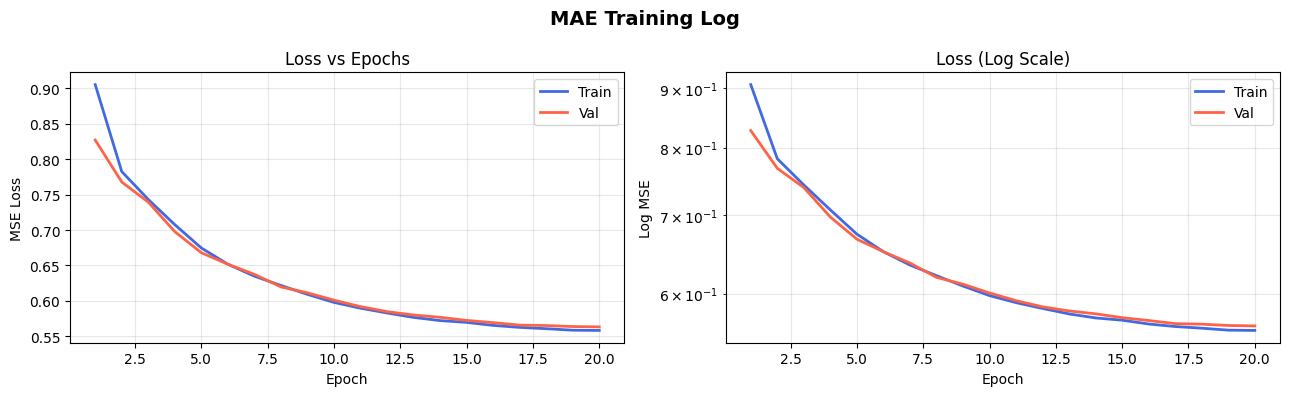

In [42]:
ep = list(range(1, len(train_losses)+1))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ep, train_losses, 'royalblue', lw=2, label='Train')
axes[0].plot(ep, val_losses,   'tomato',    lw=2, label='Val')
axes[0].set(xlabel='Epoch', ylabel='MSE Loss', title='Loss vs Epochs')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].semilogy(ep, train_losses, 'royalblue', lw=2, label='Train')
axes[1].semilogy(ep, val_losses,   'tomato',    lw=2, label='Val')
axes[1].set(xlabel='Epoch', ylabel='Log MSE', title='Loss (Log Scale)')
axes[1].legend(); axes[1].grid(alpha=0.3, which='both')
plt.suptitle('MAE Training Log', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 13 — Visualise Reconstructions

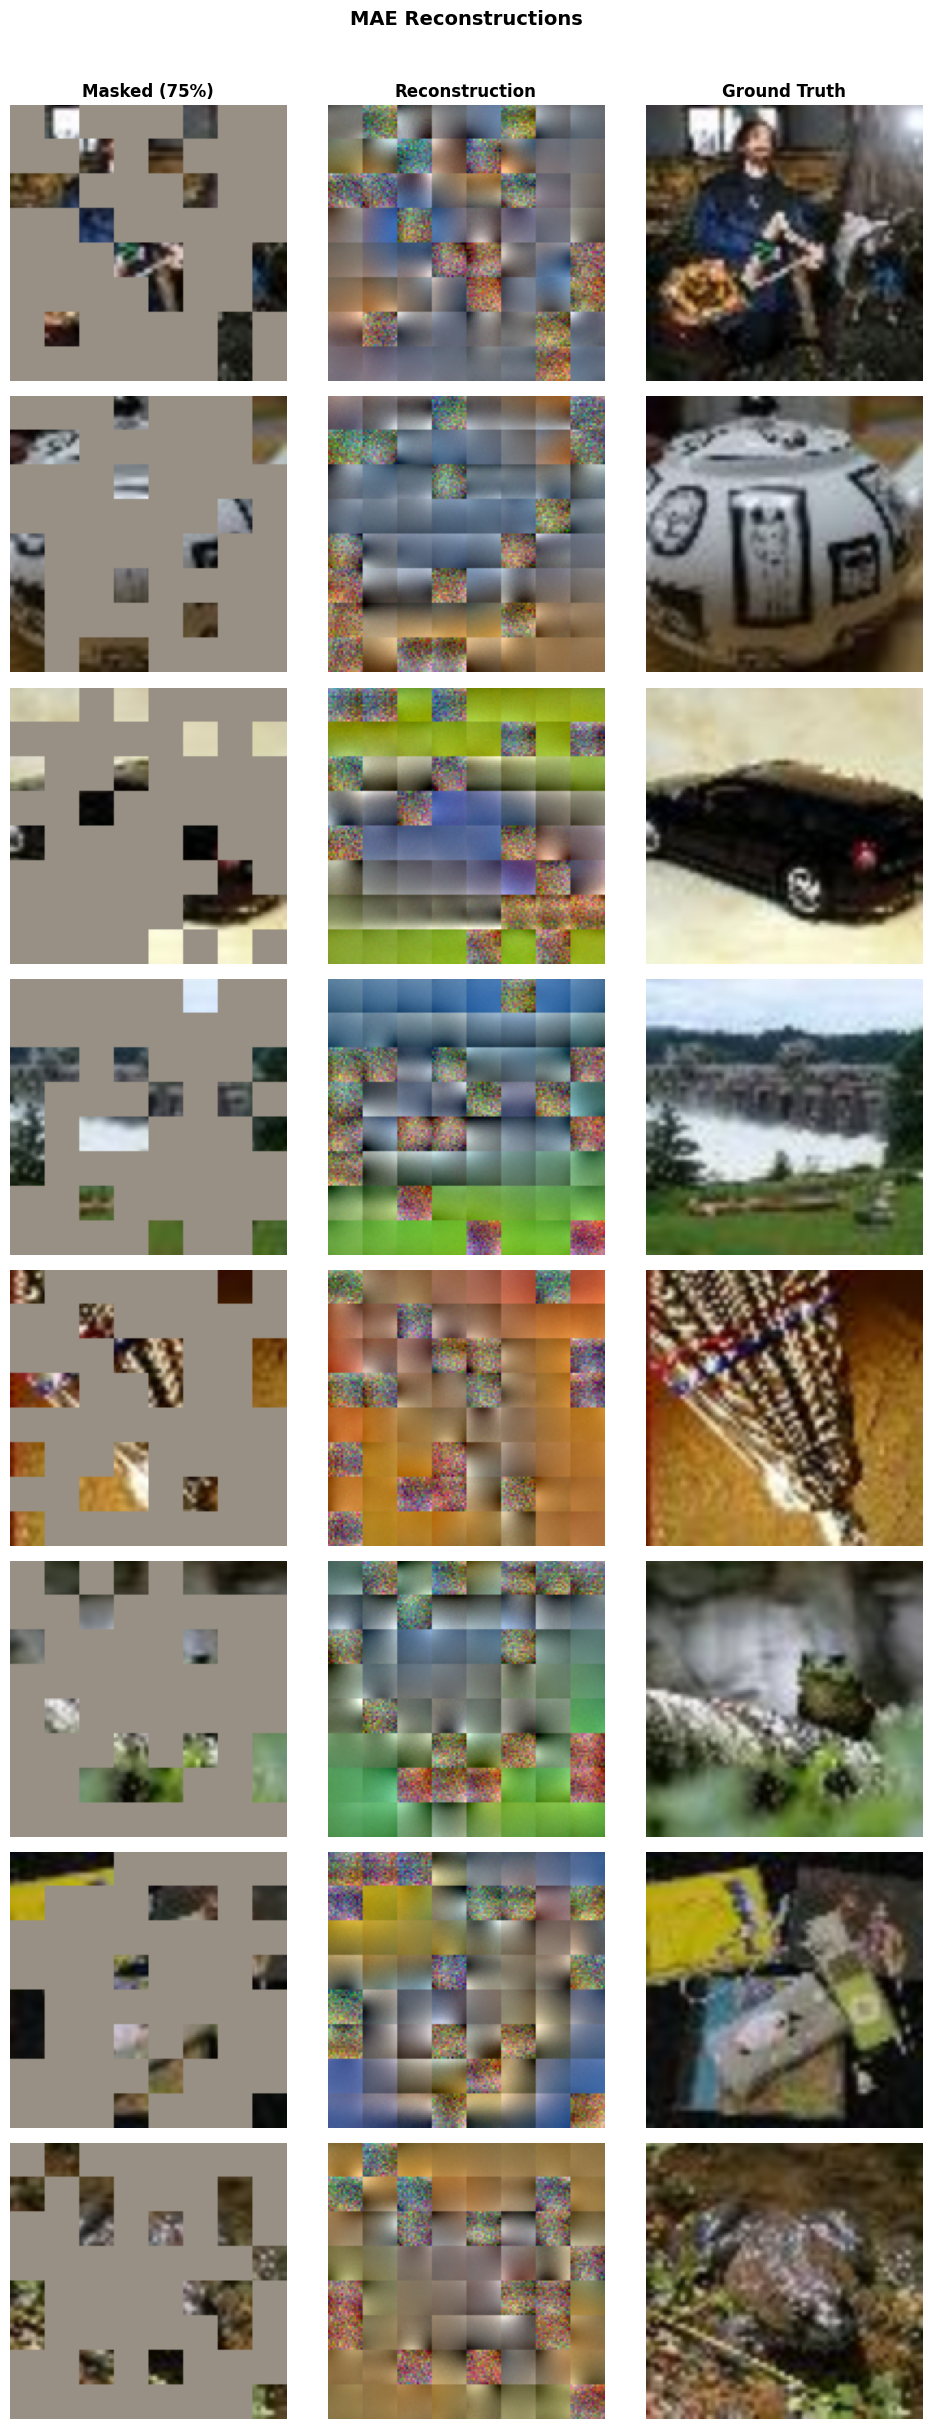

In [43]:
_mt = torch.tensor(MEAN).view(3,1,1)
_st = torch.tensor(STD).view(3,1,1)

def denorm(t):
    t = t.cpu().float() * _st + _mt
    return (t.clamp(0,1).permute(1,2,0).numpy() * 255).astype(np.uint8)

def overlay_mask(imgs_cpu, mask_cpu, p=PATCH_SIZE):
    out = imgs_cpu.clone()
    B, C, H, W = out.shape
    n = H // p
    for b in range(B):
        for idx in range(mask_cpu.shape[1]):
            if mask_cpu[b, idx] == 1:
                r = (idx // n) * p;  c = (idx % n) * p
                out[b, :, r:r+p, c:c+p] = 0.5
    return out

def visualise(n=8):
    m = model.module if hasattr(model, 'module') else model
    m.eval()
    imgs, _ = next(iter(val_loader))
    imgs = imgs[:n].to(device)
    with torch.no_grad(), autocast():
        latent, mask, ids = m.encoder(imgs)
        recon = m.unpatchify(m.decoder(latent, ids))
    masked = overlay_mask(imgs.cpu(), mask.cpu())
    fig, axes = plt.subplots(n, 3, figsize=(10, 3*n))
    for i in range(n):
        for j, (arr, title) in enumerate([
            (denorm(masked[i]),      'Masked (75%)'),
            (denorm(recon[i].cpu()), 'Reconstruction'),
            (denorm(imgs[i].cpu()),  'Ground Truth'),
        ]):
            axes[i,j].imshow(arr); axes[i,j].axis('off')
            if i == 0: axes[i,j].set_title(title, fontsize=12, fontweight='bold')
    plt.suptitle('MAE Reconstructions', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('/kaggle/working/reconstructions.png', dpi=150, bbox_inches='tight')
    plt.show()

visualise()

## Cell 14 — PSNR & SSIM

Samples: 640 | PSNR: 11.92 dB (std 1.93) | SSIM: 0.1928 (std 0.0570)


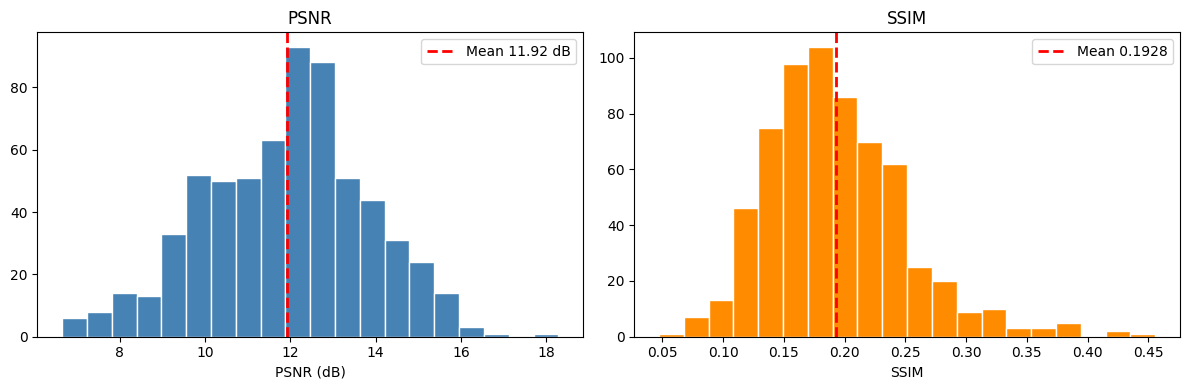

In [44]:
def evaluate(n_batches=5):
    m = model.module if hasattr(model, 'module') else model
    m.eval()
    psnr_list, ssim_list = [], []
    with torch.no_grad(), autocast():
        for i, (imgs, _) in enumerate(val_loader):
            if i >= n_batches: break
            imgs  = imgs.to(device)
            latent, mask, ids = m.encoder(imgs)
            recon = m.unpatchify(m.decoder(latent, ids))
            for j in range(imgs.shape[0]):
                gt  = denorm(imgs[j].cpu()).astype(np.float32) / 255.
                rec = denorm(recon[j].cpu()).astype(np.float32) / 255.
                psnr_list.append(calc_psnr(gt, rec, data_range=1.0))
                ssim_list.append(calc_ssim(gt, rec, data_range=1.0, channel_axis=2))
    p, s = np.array(psnr_list), np.array(ssim_list)
    print(f'Samples: {len(p)} | PSNR: {p.mean():.2f} dB (std {p.std():.2f}) | SSIM: {s.mean():.4f} (std {s.std():.4f})')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.hist(p, bins=20, color='steelblue', edgecolor='white')
    ax1.axvline(p.mean(), color='red', lw=2, ls='--', label=f'Mean {p.mean():.2f} dB')
    ax1.set(xlabel='PSNR (dB)', title='PSNR'); ax1.legend()
    ax2.hist(s, bins=20, color='darkorange', edgecolor='white')
    ax2.axvline(s.mean(), color='red', lw=2, ls='--', label=f'Mean {s.mean():.4f}')
    ax2.set(xlabel='SSIM', title='SSIM'); ax2.legend()
    plt.tight_layout()
    plt.savefig('/kaggle/working/metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    return p, s

psnr_scores, ssim_scores = evaluate()

## Cell 15 — Gradio App

In [45]:
import gradio as gr

def mae_predict(pil_img, mask_ratio):
    if pil_img is None: return None, None, None
    m = model.module if hasattr(model, 'module') else model
    m.eval()
    img_t = norm_fn(to_tensor(pil_img.resize((IMG_SIZE, IMG_SIZE)).convert('RGB')),
                    MEAN, STD).unsqueeze(0).to(device)
    with torch.no_grad(), autocast():
        latent, mask, ids = m.encoder(img_t, mask_ratio=float(mask_ratio))
        recon = m.unpatchify(m.decoder(latent, ids))
    masked_t = overlay_mask(img_t.cpu(), mask.cpu())[0]
    to_pil = lambda t: Image.fromarray(denorm(t))
    return to_pil(masked_t), to_pil(recon[0].cpu()), to_pil(img_t[0].cpu())

with gr.Blocks(title='MAE Demo', theme=gr.themes.Soft()) as demo:
    gr.Markdown('# MAE — Real-Time Image Reconstruction')
    with gr.Row():
        with gr.Column(scale=1):
            img_in   = gr.Image(type='pil', label='Upload Image')
            ratio_sl = gr.Slider(0.1, 0.95, value=0.75, step=0.05, label='Masking Ratio')
            btn      = gr.Button('Reconstruct', variant='primary')
        with gr.Column(scale=2):
            with gr.Row():
                out1 = gr.Image(label='Masked Input')
                out2 = gr.Image(label='Reconstruction')
                out3 = gr.Image(label='Ground Truth')
    btn.click(mae_predict, [img_in, ratio_sl], [out1, out2, out3])
    ratio_sl.change(mae_predict, [img_in, ratio_sl], [out1, out2, out3])

demo.launch(share=True, quiet=True)
print('Gradio app launched ✓')

* Running on public URL: https://94501403640e08e0a3.gradio.live


Gradio app launched ✓
